<a href="https://colab.research.google.com/github/R23062/idk/blob/main/eii2_%E7%AC%AC02%E5%9B%9E_2026_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# matplotlib で日本語を使用するためのパッケージのインストール
!pip install japanize_matplotlib

テーマ[第1回](https://colab.research.google.com/drive/1RBAoN61KZ_OAurQxfqFitS_FvOiis19l?usp=sharing)では「**記述統計**」について学びました。

第2回から第4回かけては、「**推測統計**」について、じっくりと学んでいきます。

**🗨️<font color="deeppink">プロンプト例</font>**

> 1週間前にも尋ねたと思うのですが「推測統計」ってなんですかぁ？「記述統計」との違いについて、文系の高校生でも無理なく理解できるように解説してください😆

**第2回**では、次の3つを「目的」として設定しています。

### **<font color="deeppink">目的1</font>**

**母平均**（＝母集団の平均）$\mu$ が、次のように標本に基づいて「**点推定**」できることを、Python を用いたシミュレーション実験（＝<font color="deeppink">反復的なサンプリングと可視化</font>）により実証的に確認し、その理解を深める。

> 平均および分散が未知の母集団から無作為抽出した標本 $(x_1, x_2, \ldots, x_n)$ がある。  
> このとき、標本平均 $\bar{x}$ は、母平均 $\mu$ の「**点推定量**」となる。
>  
> $$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n}x_{i}$$
>  
> 母集団の分布形状に関わらず、十分に大きな標本を繰り返し抽出するとき、それらの **標本平均の分布** は、正規分布に近似的に従う。  
> 👉 中心極限定理（教科書 p.82）

- 「正規分布」の概要については、情報1（第12回講義）、情報2（第01回講義）、情報3（第09回講義）で学習済みです。高校数学の範囲でもあり、YouTubeにも動画がありますので参考にしてください。
   - 正規分布は「ガウス分布」とも呼ばれます。

**🗨️<font color="deeppink">プロンプト例</font>**

> 推測統計の文脈で「標本（サンプル）」とは何ですか？

> 推測統計の文脈で「サンプリング（標本抽出）」とは何ですか？

### **<font color="deeppink">目的2</font>**

**母分散**（＝母集団の分散）$\sigma^2$ が、次のように標本に基づいて「**点推定**」できることを、Python を用いたシミュレーション実験を通じて実証的に確認し、その理解を深める。

> 標本から計算される不偏分散 $u^2$（`ddof=1`）は、母分散 $\sigma^2$ の「**点推定量**」となる。
>  
> $$ u^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 $$

- 偏差の2乗和を「$n$」ではなく「<font color="deeppink">$n-1$</font>」で除している点に注意してください。
    - これは、母分散 $\sigma^2$ を過小評価しないようにするための補正であり、その意味を実験を通して理解します。
    - この補正は経験的に定められたものではなく、理論的に導出ができます（興味がある人は深掘りしてみてください）。

母分散 $\sigma^2$ の推定値は、「区間推定」や「検定」の土台となるパラメータとして利用されることが多いです。また、品質管理では「安定性の評価」や「外れ値の検出」など、ばらつきそのものを評価するために直接的に用いられることがあります。

**🗨️<font color="deeppink">プロンプト例</font>**

> 品質管理において、母分散の点推定（不偏分散など）が「安定性の評価」や「外れ値の検出」に利用されると聞きました。しかし、その具体的な使われ方のイメージがつかめていません。製造業などの具体例を用いて説明してください。

> 母分散の推定では、偏差の2乗和を n ではなく n-1 で除します。なぜ n-1 とするのかについて理論的に導出してください。高校卒業程度の数学知識を前提に説明をお願いします。

### **<font color="deeppink">目的3</font>**

**母平均** $\mu$ の「$95\%$信頼区間」が、次のように標本に基づいて「**区間推定**」できることを、Python を用いたシミュレーション実験を通じて実証的に確認し、その理解を深める。

> $$ \left[ \bar{x} - t \cdot \mathrm{SE},\; \bar{x} + t \cdot \mathrm{SE} \right] = \left[ \bar{x} - t \cdot \frac{u}{\sqrt{n}},\; \bar{x} + t \cdot \frac{u}{\sqrt{n}} \right] $$
>
> ここで $t$ は、自由度 $n-1$ の「$t$ 分布」における上側確率 $2.5\%$ 点の値とする。
>  
> また、$\mathrm{SE}$ は、標本平均 $\bar{x}$ のばらつき（推定の不確かさ）を表す**標準誤差**とする。

例えば、自由度 $9$ の上側確率 $2.5\%$ 点の値は、次の図から読み取れるように「<font color="deeppink">$2.26$</font>」となります。詳しくは、資料のなかで解説します。





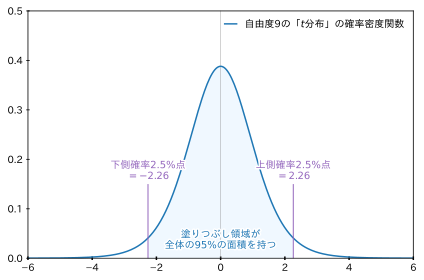

In [ ]:
#@title 参考：区間推定に使用する t（95%）の例 { display-mode: "form" }
# 現時点で、このプログラムを理解する必要はありません。
%reset -f
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 確率密度関数 PDF: Probability Density Function
# 累積確率分布関数 CDF: Cumulative Distribution Function

fig,ax = plt.subplots(figsize=(6,4),facecolor='white')

n = 10
x = np.linspace(-6, 6, 300)
t_dist_pdf = scipy.stats.t.pdf(x, df=n-1)  # 確率密度関数 PDF

ax.axvline(0,c='gray',lw=0.5, alpha=0.7)

# 確率密度関数の描画
ax.plot(x, t_dist_pdf, color='tab:blue', lw=1.5,label=f'自由度{n-1}の「$t$分布」の確率密度関数')

# 累積確率 0.025 〜 0.975 に対応する t値を取得
t_left = scipy.stats.t.ppf(0.025, df=n-1)
t_right = scipy.stats.t.ppf(0.975, df=n-1)

for t in [(t_left,'下側'), (t_right,'上側')]:
  ax.vlines(t[0],ymin=0,ymax=0.15,color='tab:purple',lw=1)
  text=ax.text(t[0],0.16,f'{t[1]}確率$2.5\\%$点\n$={t[0]:.2f}$',ha='center',c='tab:purple')
  text.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])

# 塗りつぶす範囲（t_left 〜 t_right）
mask = (x >= t_left) & (x <= t_right)
x_fill = x[mask]
y_fill = t_dist_pdf[mask]

text=ax.text(0,0.02,f'塗りつぶし領域が\n全体の$95\\%$の面積を持つ',ha='center',c='tab:blue')
text.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])

# 塗りつぶし
ax.fill_between(x_fill, y_fill, color='aliceblue')

# 軸設定など
ax.set_xlim(-6, 6)
ax.set_ylim(0, 0.5)
ax.tick_params(axis='x', direction='inout', width=1.5)
ax.tick_params(axis='y', direction='inout')
ax.legend(handlelength=1.2, frameon=False)

plt.tight_layout()
plt.show()

以降の「**実験**」セクションで取り組む内容は、次週以降の内容とあわせて**報告書1として提出**してもらいます。

実験にあたっては、実行結果を記録するだけでなく、<font color="deeppink">**再現性を確保することを重視し、適切にプログラムを実装して、再実行すれば同じ結果が得られるようにしておいてください**</font>。

- 👉 [2025年度 報告書1（参考）](https://colab.research.google.com/drive/1ukjsZuQVCJErPq0lgp0uXDPV3U9GfcVC?usp=sharing)
  - 上記は昨年度のものであり、あくまで **参考** として参照ください。詳細は次週に案内します。

<font color="deeppink">注意</font> いずれの実験も、単に計算式に数値を当てはめて各種統計量を算出するだけでなく、その背後にある「確率的な現象」を体験的かつ実証的に捉え、各統計量が何を意味しているのか、その意味理解まで踏み込むことに努めてください。


### キーワード

目的1～3のなかでは、次のようなキーワードが出てきています。本実験を通して、それらの意味を正しく理解し、自分の言葉で説明できるようになってください。

- **点推定** と **区間推定**
- **点推定量** と **信頼区間**（95%信頼区間）
- **標本平均** $\bar{x}$ と **母平均** $\mu$  
- 標本から計算される**不偏分散** $u^2$ と **母分散** $\sigma^2$
- **自由度** と **自由度の調整量** `ddof`
- **標準誤差**
  - 標本平均 $\bar{x}$ の分布のばらつき、すなわち標本平均による母平均 $\mu$ の推定の不確かさ

# 📈 **実験1：母平均の点推定**

これは[目的1](#scrollTo=pFRQ7GnK-2eE)に対応した実験です。

教科書 p.91 には【問7.1】として、次のような問題が示されています。

> あるマンションに住む各世帯の月ごとのガス使用量 \[ $\mathrm{m}^3/$月 \] の平均を調べるため、無作為に $10$ 世帯を選び出し調査したところ、次の標本が得られた。これらから、マンション全世帯のガス使用量の平均 $\mu$ および 分散 $\sigma^2$ を不偏推定値により、点推定せよ。値は小数第 $3$ 位を四捨五入せよ。  
>
> 35.53　28.27　37.31　28.11　18.56　27.48　35.68　40.23　29.09　37.45

ここでは、まずは**母平均** $\mu$（＝<font color="deeppink">母集団であるマンション全世帯のガス使用量の平均</font>）の「**点推定**」だけを考えます。分散の点推定については「実験2」で扱います。

---

**🗨️<font color="deeppink">プロンプト例</font>**

> 統計学における「**不偏**」とは、どのような意味ですか？また「**不偏推定値**」とは何ですか？初学者向けに数式を使わずに分かりやすく概念を説明してください。ここでは、理解の妨げにならないように厳密さをある程度犠牲にして、分かりやすさを優先して説明してください。

---

母平均 $\mu$ は、標本平均 $\bar{x}$ を用いて次のように「**点推定**」することができます。

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n}x_{i}$$

このガス使用量のケースでは、$\bar{x}=31.77$ となるため、母平均 $\mu$ の推定値は $31.77$ となります。


🚨🚨🚨 <font color='deeppink'>大事なのは、ここからです</font> 🚨🚨🚨

しかし、別の $10$ 世帯を選んで標本平均 $\bar{x}$ を再計算すると、当然ながら $31.77$ とは異なる値になります。例えば、$\bar{x}=22.8$ となる場合もあれば、$\bar{x}=42.6$ となる場合もあります。<br>&nbsp;

このように、標本平均 $\bar{x}$ は標本の取り方によって変化する統計量であり、**確率変数（不確実性を伴う値）** となります。そのため、<font color="deeppink">$\bar{x}$ に基づく母平均 $\mu$ の推定値もまた、不確実性を含んだもの</font> となります。<br>&nbsp;

以上のことから、標本平均 $\bar{x}$ という単一の値だけで結論を出すのは、**ばらつきを無視した危険な判断であり、統計的には許されません**。PBLや研究において、プレゼン資料や報告書を作成する際には、十分に注意してください。

<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1P7-2PQbRdHiYtmekxFrv2iSey5pn4A1l">
</p>




(やりがちなNG例)

> A君は、ある SNS の UI の設計と実装を担当している。A君は、コンテンツ閲覧数の増加を目的に UI を改良し、それを無作為に抽出した $50$ 人のユーザに対して適用した。
>
> このとき、「新UI」は「現行UI」と比較して、平均で 1 日あたり 5.5 件のコンテンツ閲覧数の増加を示した。そして、この結果を根拠に、「新UI」を全ユーザに適用することをプレゼンで提案した。

<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1YBKkf5ACCnAyd68e4U_ruKM35Yhbb6DN">
</p>

上記について「確率統計的な観点からどのような問題があるか」を考えてみてください。また、その問題に気づいてもいない A君 に対して、どのように声をかければよいかを、A君の教育係になったつもりで考えてみてください。

- 例：<font color='white'>なるほど、平均で $5.5$ 件増えたのか。でも、これって偶然そうなっただけかもしれないよね。例えば、コインを $10$ 回投げて『表が $7$ 回、裏が $3$ 回』だったとして、それだけでそのコインは表が出やすいと確信できるかな？もう少し確かめた方がよさそうだね。</font>

- 例：<font color='white'>その結果、面白いね。ただ気になるのは、この $50$ 人の中で、例えば $1$ 人だけが大きく増えて（例えば $100$ 件など）、残りの人はほとんど変わらない、あるいは減っている可能性はないかな？平均だけを見ると、そういう極端なケースが隠れてしまうんだよね。</font>

👆 白文字で記載されています。マウスで選択して反転すると確認できます。

以下では「**標本平均 $\bar{x}$ が母平均 $\mu$ に対してどの程度の不確実性を持つか**」について検証するための実験を設計し、プログラムを用いて実際に実験を行い、その結果を分析・考察してください。





## 参考


実験を設計するための「**参考**」として、次のような処理をするサンプルプログラムを示します。これを参考に実験用プログラムを作成してください。

1. $N$ 個の要素からなる母集団を生成する。あわせて、その母集団の分布を確認するため、要素の値のヒストグラムを描画する。
2. 母集団の平均（母平均 $\mu$）を計算して出力する。
3. 母集団から無作為抽出により $n$ 個の要素からなる標本を $m$ 個得る。
    - サンプルサイズ $n$ で、$m$ 回のサンプリングを実行する。
4. 各標本（$i = 1, 2, \ldots, m$）について、標本平均 $\bar{x}_i$ を算出する。
5. $m$ 個の標本平均列（$\bar{x}_1$, $\bar{x}_2$, $\ldots$, $\bar{x}_m$) について、「標本平均 $\bar{x}_i$ の平均」と「標本平均 $\bar{x}_i$ の 標準偏差 $s_{\bar{x}}$」を計算する。
    - 標本平均 $\bar{x}_i$ の標準偏差 $s_{\bar{x}}$ を「**標準誤差（SE: Standard Error）**」という。
6. 標本平均 $\bar{x}_i$ の分布（＝ばらつき）を確認するヒストグラムを描画する。
    - 母平均 $\mu$ を表す垂直線をヒストグラム上に描画する。
    - 標本平均の平均 $\pm$ 標準誤差の範囲を塗りつぶしで描画する。
7. ヒストグラムの面積が $1$ になるようにヒストグラムを正規化し（`density=True`）、そこに、標本平均列 $\bar{x}_1$, $\bar{x}_2$, $\ldots$, $\bar{x}_m $ の「平均」と「標準偏差 $s_{\bar{x}}$」に基づく正規分布の確率密度関数を重ねて描画する。
   - 確率密度関数（PDF: Probability Density Function）<br>&nbsp;



特に、点推定の観点から、**次の関係を視覚的に理解できるグラフを作成し、その結果をもとに分析・考察すること**を期待しています。

- 母平均 $\mu$ と 標本平均 $\bar{x}$（および標本平均の平均）の関係
- 母集団の分布（形状）と 標本平均 $\bar{x}$ の分布の関係
    - 標本平均 $\bar{x}$ の分布は、母集団の分布（平均・分散・形状）に影響を受けるのか、受けないのか。
    - 影響を受けるとすれば、それはどのようなものか。
- サンプルサイズ $n$ と 標準誤差 $\mathrm{SE}$ の関係
    - $n$ が大きくなると $\mathrm{SE}$ は、大きくなるのか、小さくなるのか、変化しないのか。
- サンプリング回数 $m$ と 標準誤差 $\mathrm{SE}$ の関係
    - $m$ が大きくなると $\mathrm{SE}$ は、大きくなるのか、小さくなるのか、変化しないのか。
- 母標準偏差 $\sigma$ と 標準誤差 $\mathrm{SE}$ の関係
    - $\sigma$ が大きくなると $\mathrm{SE}$ は、大きくなるのか、小さくなるのか、変化しないのか。

上記のための実験プログラムは、**<font color="deeppink">手作業による実験結果の集計や結合は避け、それらがプログラムの実行結果として直接的に得られるように実装してください</font>**。具体的には、次のことを守ってください。

- データ処理や統計分析のプロセスを **自動化するプログラム** を作成してください。
- 計算結果を一度出力してから手作業で再計算したり、異なるデータセットを手動で結合したりするのではなく、プログラム内ですべての処理を完結させるようにしてください。
- 分析や考察に必要な統計量や可視化結果など、最終成果物がプログラムの実行によって直接的に出力されるようにしてください。

まずは、以下のサンプルプログラムを読解し、それを参考に実験用のプログラムを作成してください。

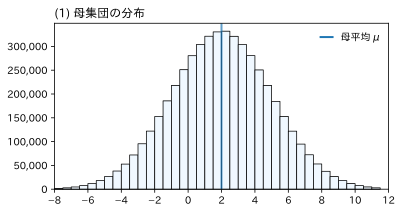

■ 母平均 = 1.998   母標準偏差 = 3.000 
■ 標本平均の平均 = 1.976   標本平均の標準偏差（標準誤差SE）= 0.955




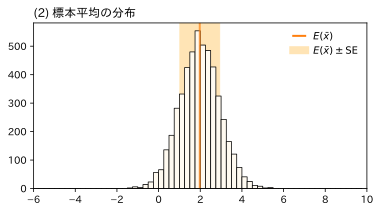

■ 標本平均の平均±標準誤差の範囲内にある標本平均を持つ標本の割合 = 0.689 (68.9%)




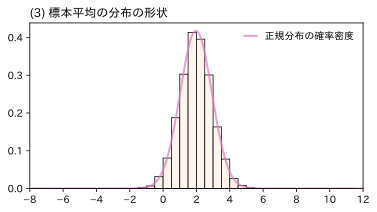

In [ ]:
#@title 実験1のための参考コード { display-mode: "form" }

# このプログラムの内容は十分に理解する必要があります。

# このプログラムは「実験1」で要求している内容の5割程度しか対応
# できていないものなので注意してください。
#  → つまり、拡張してください。

%reset -f
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tk
import japanize_matplotlib
import scipy.stats
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

def main() :
  # ■ 1. N個の要素からなる母集団を生成する。
  #       母集団の分布を確認のためにヒストグラムを描画

  N = 5_000_000

  ## [1] 正規分布に従う母集団の生成 loc=平均, scale=標準偏差
  population = np.random.normal(loc=2,scale=3,size=N)

  ## [2] 指数分布
  # population = np.random.exponential(scale=2.0, size=N)

  ## [3] 一様分布
  # population = np.random.uniform(low=-6, high=10, size=N)

  ## [4] 二峰分布
  # p1 = np.random.normal(loc=-2,scale=1.8,size=N//2)
  # p2 = np.random.normal(loc=6,scale=0.8,size=N//2)
  # population = np.concatenate([p1,p2])

  fig,ax = plt.subplots(figsize=(6,3),facecolor='white')
  ax.set_title('(1) 母集団の分布', loc='left')
  x_min, x_max, bw = (-8,12,0.5)
  bins = np.arange(x_min,x_max,bw)
  ax.axvline(population.mean(),c='tab:blue',lw=2, alpha=0.7) # 母平均を描画
  ax.hist(population, bins, color='aliceblue', edgecolor ='black',linewidth=0.75)
  ax.set_xticks(np.arange(x_min,x_max+1,2))
  ax.set_xlim(x_min,x_max)
  ax.yaxis.set_major_formatter(tk.StrMethodFormatter('{x:,.0f}'))
  legend_elements = [Line2D([0], [0], color='tab:blue',lw=2,label=r'母平均 $\mu$')]
  ax.legend(handles=legend_elements,handlelength=1.2,frameon=False)
  plt.show()
  # return # 順次コメントアウトしていくこと

  # ■ 2. 母集団の平均（母平均 $\mu$）を計算して出力する。
  mu = population.mean()
  sigma = population.std(ddof=0)
  print(f'■ 母平均 = {mu:.3f}   母標準偏差 = {sigma:.3f} ')
  # return # 順次コメントアウトしていくこと

  # ■ 3. 母集団から、無作為抽出により n 個の要素からなる m 個の標本を得る。
  n = 10     # サンプルサイズ（1個の標本を構成するデータ数）
  m = 5000   # サンプリング回数
  samples = np.random.choice(population, size=(m,n), replace=True) # 復元抽出
  # return # 順次コメントアウトしていくこと

  # ■ 4. 各標本について、標本平均 を算出する。
  sample_means = samples.mean(axis=1) # 標本平均の計算
  # print(sample_means.shape) # => (5000,)
  # return # 順次コメントアウトしていくこと

  # ■ 5. 標本平均の「平均」と「標準偏差」を計算する。
  sample_means_ave = sample_means.mean()
  sample_means_sd  = sample_means.std(ddof=0) # 標本平均の標準偏差=標準誤差
  print(f'■ 標本平均の平均 = {sample_means_ave:.3f}', end='')
  print(f'   標本平均の標準偏差（標準誤差SE）= {sample_means_sd:.3f}')
  print('\n')

  # return # 順次コメントアウトしていくこと

  # ■ 6. 標本平均 $\bar{x}_i$ の分布を表すヒストグラムを描画する。
  fig,ax = plt.subplots(figsize=(6,3),facecolor='white')
  ax.set_title('(2) 標本平均の分布', loc='left')
  bins = np.arange(x_min,x_max,bw/2)
  ax.axvline(sample_means_ave,c='tab:orange',lw=2, alpha=0.7) # 標本平均の平均
  ax.axvspan(sample_means_ave - sample_means_sd, # 標準平均の平均±標準誤差
            sample_means_ave + sample_means_sd,
            color='moccasin')
  ax.hist(sample_means, bins, color='floralwhite', edgecolor ='black',linewidth=0.75)
  ax.set_xticks(np.arange(x_min,x_max+1,2))
  ax.set_xlim(x_min+2,x_max-2)
  legend_elements = [Line2D([0], [0], color='tab:orange',lw=2,label='$E(\\bar{x})$'),
                     Line2D([0], [0], color='moccasin',lw=8,label='$E(\\bar{x})\\pm \\mathrm{SE}$'),]
  ax.legend(handles=legend_elements,handlelength=1.2,frameon=False)

  plt.show()

  # 標本平均の平均±標準誤差の範囲内にあるデータ件数をカウントしたい
  lower = sample_means_ave - sample_means_sd
  upper = sample_means_ave + sample_means_sd
  c = (sample_means >= lower) & (sample_means <= upper)
  print('■ 標本平均の平均±標準誤差SEの範囲内にある標本平均を持つ標本の割合 = ',end='')
  print(f'{c.sum() /m:.3f} ({c.sum() /m:.1%})')
  print('\n')

  # return # 順次コメントアウトしていくこと

  # ■ 7. 標本平均 $\bar{x}$ のヒストグラムについて、
  #       面積が1.0になるように正規化して、正規分布の確率密度関数を重ね書きする。
  fig,ax = plt.subplots(figsize=(6,3),facecolor='white')
  ax.set_title('(3) 標本平均の分布の形状', loc='left')
  bins = np.arange(x_min,x_max,bw)
  ax.hist(sample_means, bins, color='seashell', edgecolor ='black',linewidth=0.75, density=True)
  x = np.linspace(x_min, x_max, 400)
  norm_dist_pdf = scipy.stats.norm.pdf(x, loc=sample_means_ave, scale=sample_means_sd)
  # norm_dist_pdf = scipy.stats.norm.pdf(x, loc=mu, scale=sigma/n**0.5) # 注意！
  ax.plot(x, norm_dist_pdf, color='tab:pink', lw=2, alpha=0.7, label='正規分布の確率密度')
  ax.legend(fontsize=8,handlelength=1.2,frameon=False)
  ax.set_xticks(np.arange(x_min,x_max+1,2))
  ax.set_xlim(x_min,x_max)
  ax.legend(handlelength=1.2,frameon=False)

main()

- 指数分布や二峰分布（二峰性分布）を対象とした実験した結果からも明らかなように「**標本平均から推定する母平均の値**」と「**母集団内でどのような値のデータが多く出現するか**」には関連性がないケースも多いので、注意してください。
- 標本平均 $\bar{x}_i$ の分布（ヒストグラム）が、平均 $\mu$、分散 $\frac{\sigma^2}{n}$ の正規分布に従うことを確認してください。
    - 教科書 p.82【中心極限定理】

### 定着確認

- 標準誤差 $\mathrm{SE}$ とは何か。
  - 解答例：<font color='white'>母集団から繰り返し標本を抽出して、それぞれの標本平均 $\bar{x}$ を計算したときのばらつき（標準偏差）をあらわす指標</font>

## **補足**

「実験1」を通して、標本平均には「ばらつき」があること、つまり、「**母平均の点推定にはばらつき（不確実性）があること**」が確認できました。

また、このばらつきは「標準誤差（SE）」という指標で定量化できることも分かりました。言い換えれば「**<font color="deeppink">標準誤差を用いることで、点推定の精度を評価できる可能性があること</font>**」が確認できました。

しかし、実務において、「実験1」のように「**複数回の標本抽出を繰り返して標準誤差を求めること**」は一般に困難です。

そこで有用となるのが、次に示す標準誤差（$\mathrm{SE}$）の「**推定式**」となります。

$$ \mathrm{SE} = \frac{u}{\sqrt{n}} $$

ここで、$n$ はサンプルサイズ、$u$ は不偏標準偏差（`ddof=1`）を表します。この推定式を用いれば、<font color="deeppink">$1$ 回のサンプリングによって標準誤差（推定値）を得ることができます</font>。

なお、この式の背景には、標本平均の分散が

$$ \mathrm{Var}(\bar{\mathrm{X}}) = \frac{\sigma^2}{n} $$

となるという理論的結果があります。興味のある学生は数学的な導出過程について調べてみてください。

この推定式からは、次のような関係が読み取れます。

- サンプルサイズ $n$ が大きくなるほど標準誤差 $ \mathrm{SE} $ は小さくなる（＝母平均の推定の信頼性が向上する）
- 標本内のデータのばらつき $u$ が小さいほど、標準誤差 $ \mathrm{SE} $ も小さくなる（＝母平均の推定の信頼性が向上する）

これらの関係は直感的にも理解できると思いますし、「実験1」の結果とも一致します。

また、（実際には稀ですが）母集団の標準偏差 $\sigma$ が既知である場合には、次式から標準誤差 $ \mathrm{SE} $ を正確に求めることができます。

$$ \mathrm{SE} = \frac{\sigma}{\sqrt{n}} $$

ここで、**<font color="deeppink">標準誤差の推定式の妥当性</font>** について、実験的に確認してみます。まずは、母集団から標本抽出を繰り返したときの標本平均の標準偏差が $\sigma/\sqrt{n}$ と一致することを確認してみます。  

母標準偏差 = 2.9988


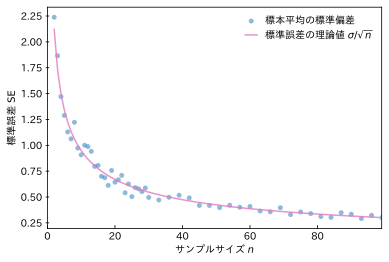

In [ ]:
#@title 「標本平均の標準偏差」と「理論式による標準誤差」を比較する補足実験 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.ticker as tk
import japanize_matplotlib
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 母集団の生成
# - 母集団の分布の切替えて実験してみてください
# - 母集団のばらつき scale を変化させて実験してみてください
N = 5_000_000
population = np.random.normal(loc=2,scale=3,size=N) # [1] 正規分布
# population = np.random.exponential(scale=2.0, size=N) # [2] 指数分布
# population = np.random.uniform(low=-6, high=10, size=N) # [3] 一様分布
# p1 = np.random.normal(loc=-2,scale=1.8,size=N//2)
# p2 = np.random.normal(loc=6,scale=0.8,size=N//2)
# population = np.concatenate([p1,p2]) # [4] 二峰分布

# 母標準偏差σを計算
sigma = population.std(ddof=0)
print(f'母標準偏差 = {sigma:0.4f}')

m = 100 # サンプリング回数（変化させて実験してみてください）
n_arr = np.concat([np.arange(2,30,dtype=np.int64),
                   np.arange(30,100,3,dtype=np.int64)])

# 標本平均の標準偏差 => 標本誤差
sample_mean_stds = np.zeros(len(n_arr),dtype=np.float64)
for i, n in enumerate(n_arr):
  samples = np.random.choice(population, size=(m,n), replace=True)
  sample_means = samples.mean(axis=1) # 標本平均を計算
  sample_mean_stds[i] = sample_means.std(ddof=0) # 標本平均の標準偏差を計算

fig,ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 標本平均の標準偏差をプロット
ax.scatter(n_arr, sample_mean_stds,
           marker='o', s=25, alpha=0.5, lw=0, label='標本平均の標準偏差')

# 母集団の標準誤差σを、サンプルサイズnの平方根で割って求めた標準誤差のプロット
n_arr2 = np.arange(2, n_arr.max())
se_theoretical = sigma/(n_arr2**0.5)
ax.plot(n_arr2, se_theoretical, c='tab:pink', alpha=0.8,
        label='標準誤差の理論値 $\\sigma/\\sqrt{n}$')

ax.set_xlim(0, n_arr.max())
ax.legend(handlelength=1.2,frameon=False)
ax.tick_params(axis='x',direction='in')
ax.tick_params(axis='y',direction='inout')
ax.set_xlabel('サンプルサイズ $n$')
ax.set_ylabel('標準誤差 $\\mathrm{SE}$')
ax.legend(handlelength=1.2, frameon=False)

plt.show()

**🗨️<font color="deeppink">プロンプト例</font>**

> このプログラムは、何を検証することを意図して作成されていますか？また、出力されるグラフをどのように読み取り、そこからどのような関係や性質が確認することを先生は期待していますか。
>  
> (ここにプログラムを貼る)

つづいて、個々の標本の不偏標準偏差 $s$ を用いた推定式による標準誤差と、理論式による標準誤差について比較、分析、考察してみます。

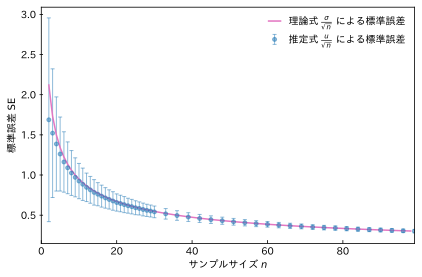

In [ ]:
#@title 「推定式による標準偏差」と「理論式による標準誤差」を比較する補足実験 { display-mode: "form" }
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 母集団の生成
# - 母集団の分布の切替えて実験してみてください
# - 母集団のばらつき scale を変化させて実験してみてください
N = 5_000_000
population = np.random.normal(loc=2,scale=3,size=N) # [1] 正規分布
# population = np.random.exponential(scale=2.0, size=N) # [2] 指数分布
# population = np.random.uniform(low=-6, high=10, size=N) # [3] 一様分布
# p1 = np.random.normal(loc=-2,scale=1.8,size=N//2)
# p2 = np.random.normal(loc=6,scale=0.8,size=N//2)
# population = np.concatenate([p1,p2]) # [4] 二峰分布

# 母標準偏差（理論値）
sigma = population.std(ddof=0)

# サンプリング設定
m = 5000  # サンプリング回数
n_arr = np.concatenate([np.arange(2, 30), np.arange(30, 100, 3)])

# 推定式による標準誤差の「平均」と「ばらつき（標準偏差）」を計算
mean_est_se = np.zeros(len(n_arr))
std_est_se = np.zeros(len(n_arr))
for i, n in enumerate(n_arr):
    samples = np.random.choice(population, size=(m, n), replace=True)
    sample_stds = samples.std(axis=1, ddof=1)  # 不偏標準偏差 s
    est_se = sample_stds / np.sqrt(n)
    mean_est_se[i] = est_se.mean()
    std_est_se[i] = est_se.std(ddof=0)

fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 推定式による標準誤差（エラーバー付き）
ax.errorbar(n_arr, mean_est_se, yerr=std_est_se, markersize=4, marker='o',
            linestyle='none', capsize=2, elinewidth=1,
            color='tab:blue', alpha=0.5,
            label=r'推定式 $\frac{u}{\sqrt{n}}$ による標準誤差')

# 理論式による標準誤差（母標準偏差ベースの標準誤差）
n_arr2 = np.arange(2, n_arr.max())
se_theoretical = sigma / np.sqrt(n_arr2)
ax.plot(n_arr2, se_theoretical, c='tab:pink', lw=1.5,
        label=r'理論式 $\frac{\sigma}{\sqrt{n}}$ による標準誤差')

# 軸と凡例
ax.set_xlim(0, n_arr.max())
ax.set_xlabel('サンプルサイズ $n$')
ax.set_ylabel('標準誤差 $\\mathrm{SE}$')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='inout')
ax.legend(handlelength=1.2, frameon=False)

plt.tight_layout()
plt.show()

サンプルサイズ $n$ が小さいとき、$s$ が $\sigma$ をやや過小評価する傾向も見られますが、本質的には $s$ のばらつきが大きいことが問題になります。この不確実性を反映するために、区間推定では「正規分布」ではなく「$t$分布」が必要となる根拠になってきます。

# 📈 **実験2：母分散の点推定**

これは[目的2](#scrollTo=pKMLs1WId7AL)に対応した実験です。

教科書 p.91 には【問7.1】として、次のような問題が示されています。

> あるマンションに住む各世帯の月ごとのガス使用量 \[ $\mathrm{m}^3/$月 \] の平均を調べるため、無作為に $10$ 世帯を選び出し調査したところ、次の標本が得られた。これらから、マンション全世帯のガス使用量の平均 $\mu$ および分散 $\sigma^2$ を不偏推定値により、点推定せよ。値は小数第 $3$ 位を四捨五入せよ。  
>
> 35.53　28.27　37.31　28.11　18.56　27.48　35.68　40.23　29.09　37.45

「実験2」では、母分散 $\sigma^2$ の点推定について考えます。母分散の点推定量（不偏分散）は、教科書 p.90 に示されるように、次式で求めることができます。

$$ 不偏分散\ u^2 = \frac{1}{n-1} \sum_{i=1}^{n} \left(x_{i}-\bar{x} \right)^2 $$

このガス使用量のケースでは、$u^2=43.30$ となるので、母分散 $\sigma^2$ の推定値（点推定量）は $43.30$ となります。

母平均 $\mu$ の点推定と同様に、母分散 $\sigma^2$ の点推定についても、<font color="deeppink">標本を再抽出すれば違う値が求まるという点に注意が必要</font> です。<br>&nbsp;

ところで、**標本そのものの分散**（標本分散）は、次のように計算することができました。不偏分散との違いは $n-1$ で割るのか、$n$ で割るのかになります。

$$ 標本分散\ s^2 = \frac{1}{n} \sum_{i=1}^{n} \left(x_{i}-\bar{x} \right)^2 $$

**<font color="deeppink">なぜ、不偏分散を求めるときは $n$ ではなく、$n-1$ を使うのでしょうか？</font>**

以下、「**母分散 $\sigma^2$ の点推定には、偏差平方和を $n$ で割った標本分散 $s^2$ ではなく、偏差平方和を $n-1$ で割った不偏分散 $u^2$ を用いるのが適切**」について実証的に確認するための実験を設計し、プログラムを利用して実際に実験して、分析・考察を行ってください。

## 参考

実験を設計するための「**参考**」として、以下の処理をするサンプルプログラムを示します。これを参考にプログラムを作成し、実験、分析、考察をしてください。

1. $N$ 個の要素からなる母集団を生成する。
2. 母集団の分散（母分散 $\sigma^2$）を計算して出力する。
3. 母集団から、無作為抽出により $n$ 個の要素からなる $m$ 個の標本を得る。
4. 各標本（$i = 1, 2, \ldots, m$）について、標本分散 $s_{i}^{2}$ と不偏分散 $u_{i}^{2}$ を算出する。
5. 次の値を計算する。
   - 標本分散（`ddof=0`）の平均 $\mathrm{E}\ (s^2_i)$
   - 不偏分散（`ddof=1`）の平均 $\mathrm{E}\ (u^2_i)$
   - 標本分散（`ddof=0`）の標準偏差 $\mathrm{SD}\ (s^2_i)$
   - 不偏分散（`ddof=1`）の標準偏差 $\mathrm{SD}\ (u^2_i)$
6. 横軸にサンプルサイズ $n$、縦軸に分散をとり、標本分散の平均 $E(s^2_i)$、不偏分散の平均 $E(u^2_i)$、母分散 $\sigma^2$ をプロットする。
    - $E(s^2_i)$ には、$SD(s^2_i)$ のエラーバーを表示する。$E(u^2_i)$ についても同様にする。

### ヒント

この実験では、単に標本分散 $s^2$ と不偏分散 $u^2$ を計算するだけでなく、多数回の標本抽出を通して、それぞれが母分散 $\sigma^2$ を平均的にどのように見積もるのかを確認してください。

特に、標本分散 $s^2$ は **平均的に母分散を過小評価しやすい**のに対し、不偏分散 $s^2$ は **平均的に母分散に近い値を与えること**を、グラフや数値をもとに考察してください。

- $\mathrm{E}\ (s^2_i)$ は母分散 $\sigma^2$ と比べて大きいか、小さいか。
- $\mathrm{E}\ (u^2_i)$ は母分散 $\sigma^2$ と比べて大きいか、小さいか。
  - サンプルサイズ $n$ が大きくなると、その差はどう変化するか。

この結果から、母分散 $\sigma^2$ の点推定としては、$s^2$ と $u^2$ のどちらが妥当か。

■ 母分散 = 9.005 


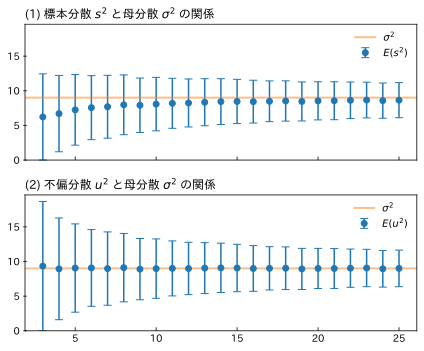

In [ ]:
#@title 実験2のための参考コード { display-mode: "form" }

# このプログラムは実験1で要求されていることについて
# 7割程度しか対応できていないものなので注意してください。

%reset -f
import sys
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

def main() :
  # ■ 1. N個の要素からなる母集団を生成する。
  # - 母集団の分布の切替えて実験してみてください
  # - 母集団のばらつき scale を変化させて実験してみてください
  ## [1] 正規分布に従う母集団の生成 loc=平均, scale=標準偏差
  N = 5_000_000
  population = np.random.normal(loc=2,scale=3,size=N)

  # ■ 2. 母集団の分散（母分散）を計算して出力する。
  sigma2 = population.var(ddof=0)
  print(f'■ 母分散 = {sigma2:.3f} ')
  # return # 順次コメントアウトしていくこと

  # ■ 3. 母集団から、無作為抽出により n 個の要素からなる m 個の標本を得る。
  # ■ 4. 各標本（ i=1,2,…,m ）について、標本分散 と 不偏分散 を算出する。
  # ■ 5. 標本分散と不偏分散の平均、標準偏差を計算する。
  m = 5000   # サンプリング回数
  n_arr = np.arange(3,26,dtype=np.int64) # サンプルサイズ
  s2_mean_arr = np.zeros(len(n_arr))    # 標本分散平均の配列
  u2_mean_arr = np.zeros(len(n_arr))    # 不偏分散平均の配列
  s2_sd_arr = np.zeros(len(n_arr)) # 標本分散の標準偏差の配列
  u2_sd_arr = np.zeros(len(n_arr)) # 不偏分散の標準偏差の配列
  # return # 順次コメントアウトしていくこと

  for i,n in enumerate(n_arr):
    samples = np.random.choice(population, size=(m,n), replace=True) # 復元抽出
    s2_mean_arr[i] = samples.var(axis=1,ddof=0).mean()
    u2_mean_arr[i] = samples.var(axis=1,ddof=1).mean()
    s2_sd_arr[i] = samples.var(axis=1,ddof=0).std(ddof=0)
    u2_sd_arr[i] = samples.var(axis=1,ddof=1).std(ddof=0)

  # ■ 6. 横軸にサンプルサイズ n 、縦軸に分散をとり、
  #       標本分散の平均、不偏分散の平均、母分散をプロットする。
  #       標本分散の平均、不偏分散の平均についてはエラーバーをつける。
  fig, axes = plt.subplots(nrows=2, ncols=1, sharex='col', sharey='col', figsize=(6,5),facecolor='white')

  # 標本分散 s^2
  ax = axes[0]
  ax.set_title('(1) 標本分散 $s^2$ と母分散 $\\sigma^2$ の関係', loc='left')
  ax.errorbar(n_arr, s2_mean_arr, yerr=s2_sd_arr, marker='o', capsize=4,
              linestyle='none', label='$E(s^2)$', )

  # 不偏分散 u^2
  ax = axes[1]
  ax.set_title('(2) 不偏分散 $u^2$ と母分散 $\\sigma^2$ の関係', loc='left')
  ax.errorbar(n_arr, u2_mean_arr, yerr=u2_sd_arr, marker='o', capsize=4,
              linestyle='none', label='$E(u^2)$', )

  # 共通
  for ax in axes:
    ax.axhline(sigma2, color='tab:orange', lw=2, alpha=0.5, label='$\\sigma^2$')
    ax.tick_params(axis='x',direction='in')
    ax.tick_params(axis='y',direction='inout')
    ax.legend(frameon=False)
    ax.set_ylim(0,)

  plt.tight_layout()
  plt.show()

main()


## **ここまでの内容についての整理**

「実験1」と「実験2」を通して、標本平均 $\bar{x}$ から母平均 $\mu$ を点推定できることが分かりました。

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n}x_{i}$$

しかし、標本平均 $\bar{x}$ は、標本を再抽出すれば変化する値であり、その解釈や、$\bar{x}$ から点推定した母平均の扱いには、十分に注意する必要があることも分かりました。

また、標本平均 $\bar{x}$ のばらつきの大きさ（再抽出によって変化する範囲）は、標準誤差（$\mathrm{SE}$）という統計量で推測ができることも分かりました。この標準誤差（$\mathrm{SE}$）は、次式のように標本の大きさ（標本を構成するデータ数）$n$ と、その不偏分散 $u^2$（不偏標準偏差 $u$）により推定できることも分かりました。

$$ \mathrm{SE} = \frac{u}{\sqrt{n}} $$

以上を総合して、母集団から無作為抽出した標本から $\bar{x}$ を得たとしても、標本抽出をやり直せば、$\bar{x}\pm\mathrm{SE}$ の範囲での変動は十分に起こり得るということも分かりました。

例えば、

> 無作為抽出した10名のユーザに対して、新しい UI を適用したところ、現行の UI と比較して、平均で $2.7$ ポイントのコンテンツ閲覧数の増加がみられた。なお、標準誤差は $4.5$ であった。

のようなケースがあったとします。このとき、別のユーザを対象に同様のテストを実施すれば、$\bar{x}$ は $2.7\pm4.5$、すなわち、$-1.8$ から $7.2$ のような値になる可能性も十分にあるということが分かると思います（新しい UI によって、閲覧数が減る可能性も十分にあり得るということです）。

以上のようなことから、より信頼性のある母平均の推定のためには、「区間推定」や「信頼区間」という考え方が必要になってきます。

※ $\bar{x}\pm\mathrm{SE}$ そのものが統計学的な信頼区間を表すわけではないので注意してください。$\bar{x}\pm\mathrm{SE}$ は、あくまで、$\bar{x}$ に対するひとつの直感的な「変動範囲」を表現しているものです。

# 📈 **実験3：母平均の区間推定**

これは[目的3](#scrollTo=zqJjJaOJd9-j)に対応した実験です。




## 区間推定・信頼区間とは

まずは、<font color='deeppink'>厳密さをある程度犠牲にして、分かりやすさを重視して説明します</font>。厳密な理解は、このあとの「実験3」を通して段階的に深めていきます。

「信頼区間」とは、**確率的に真の値を含みうると推測される区間**のことを言います。点推定では「$2.7$」のような単一の値で母平均を推定したのに対し、区間推定では「$−1.8$ から $7.2$」のように幅を持たせた区間で母平均を推定します。

実際には「$95\%$信頼区間」や「$99\%$信頼区間」などの概念を用いて、以下のように使用します。

> ある SNS の「現行UI」と「新UI」を比較するテストとして、無作為抽出した $50$ 人のユーザについて、$1$ 日あたりのコンテンツ閲覧数の変化を測定した。その結果、「新UI」は、「現行UI」と比較して平均 $5.5$ 件の閲覧数増加が観測され、その $95\%$ 信頼区間は $4.2$ 件から $6.8$ 件と算出された。

ここで、$95\%$信頼区間が $[4.2, 6.8]$ であるというのは、母集団全体における「真の平均閲覧数変化」が、この区間内に収まる確率が $95\%$ であることを意味します（実験を通して、この解釈を厳密に理解していきます）。










## 区間推定の手順

母平均を区間推定する手順について説明していきます。

なお、ここで扱う区間推定を適用するためには、「**母集団が正規分布に従うこと**」など、いくつかの前提条件があります。ただし、ここでは詳細には立ち入らず、まずは「手順・手続き」に着目して、信頼区間の求め方を理解することを目的とします。


以下は、教科書 p.95【例題 7.2】の問題です。

> ある健康食品から $10$ 個の標本を無作為抽出し、含まれるビタミンCの含有量を調べたところ、その平均値は $\bar{x}=30.3$ で、不偏分散の値は $u^2=1.7^2$ であった。この健康食品のビタミンCの平均含有量 $\mu$ の「$95\%$ 信頼区間」を求めよ。  
> ただし、ビタミンCの含有量は、正規分布に従うとし、信頼限界は小数第1位まで求めよ。

一般に、信頼区間は次の形式で求めることができます。

$$ \bar{x}\pm(係数\times \mathrm{SE}) $$

ここで「$係数$」は、信頼度（$95\%$や$99\%$など）と母集団の分布特性（正規分布かどうか、母分散が既知か未知か）によって適切に設定する必要があります。

まず、$\bar{x} = 30.3$ は問題文から与えられています。

次に、標準誤差 $\mathrm{SE}$ は以下の式で求められます。$n$ は、問題文から与えられるように $10$ です。

$$ \mathrm{SE} = \frac{u}{\sqrt{n}} = \frac{1.7}{\sqrt{10}} \fallingdotseq 0.5376 $$

つづいて「$係数$」を決めていきます。

母集団が正規分布に従い、その母分散 $\sigma^2$ が「未知」である場合には、<font color='deeppink'>自由度 $n - 1$ の「**t分布**」に基づく値</font>を用います。具体的には、t分布の確率密度関数の両側 $95\%$ 信頼区間に対応する上側 $2.5\%$ 点の **t値**（横軸の値）</font> を「$係数$」として用います。

- 確率密度関数：Probability Density Function (PDF)






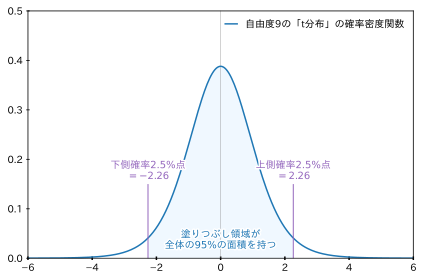

In [ ]:
#@title 区間推定に使用する t値（95%）の例 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 確率密度関数 PDF: Probability Density Function
# 累積確率分布関数 CDF: Cumulative Distribution Function

fig,ax = plt.subplots(figsize=(6,4),facecolor='white')

n = 10
x = np.linspace(-6, 6, 300)
t_dist_pdf = scipy.stats.t.pdf(x, df=n-1)  # 確率密度関数 PDF

ax.axvline(0,c='gray',lw=0.5, alpha=0.7)

# 確率密度関数の描画
ax.plot(x, t_dist_pdf, color='tab:blue', lw=1.5,label=f'自由度{n-1}の「t分布」の確率密度関数')

# 累積確率 0.025 〜 0.975 に対応する t値を取得
t_left = scipy.stats.t.ppf(0.025, df=n-1)
t_right = scipy.stats.t.ppf(0.975, df=n-1)

for t in [(t_left,'下側'), (t_right,'上側')]:
  ax.vlines(t[0],ymin=0,ymax=0.15,color='tab:purple',lw=1)
  text=ax.text(t[0],0.16,f'{t[1]}確率$2.5\\%$点\n$={t[0]:.2f}$',ha='center',c='tab:purple')
  text.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])

# 塗りつぶす範囲（t_left 〜 t_right）
mask = (x >= t_left) & (x <= t_right)
x_fill = x[mask]
y_fill = t_dist_pdf[mask]

text=ax.text(0,0.02,f'塗りつぶし領域が\n全体の$95\\%$の面積を持つ',ha='center',c='tab:blue')
text.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])

# 塗りつぶし
ax.fill_between(x_fill, y_fill, color='aliceblue')

# 軸設定など
ax.set_xlim(-6, 6)
ax.set_ylim(0, 0.5)
ax.tick_params(axis='x', direction='inout', width=1.5)
ax.tick_params(axis='y', direction='inout')
ax.legend(handlelength=1.2, frameon=False)

plt.tight_layout()
plt.show()

この図から読み取れるように、例えば、自由度 $9$ の上側確率 $2.5\%$ 点の値は、$2.26$ です。Python では、次のように計算できます。

In [ ]:
%reset -f
import scipy.stats as st

n = 10     # サンプルサイズ
cl = 0.95  # 信頼水準（Confidence Level）
alpha = 1 - cl
p = 1 - alpha / 2 # 累積確率 97.5%（上側2.5%点）
t = st.t.ppf(p, df=n-1) # => st.t.ppf(0.975, df=9)
print(f'自由度 {n-1} の「t分布」の上側確率 {alpha/2:.1%} 点の t値 は {t:.2f}')

自由度 9 の「t分布」の上側確率 2.5% 点の t値 は 2.26


以上より、

$$ \bar{x}\pm(係数\times \mathrm{SE}) = 30.3 \pm ( 2.26 \times 0.5376 )$$

母平均の $95\%$ 信頼区間は、たとえば $29.0 \le \mu \le 31.6$ のように計算されます。一般に、信頼区間を求める際は、下限は「切り捨て」、上限は「切り上げ」として、やや広めに区間をとるのが慣例になっています。

なお、信頼区間は、次のようにライブラリを使って計算することもできます。

In [ ]:
%reset -f
import math
import scipy.stats as st
n = 10
mean = 30.3
sd = 1.7 / n**0.5
a = 0.95
ci = st.t.interval(df=n-1, loc=mean, scale=sd, confidence=a)
print(f'[{ci[0]:.2f}, {ci[1]:.2f}]')

[29.08, 31.52]


## 練習

教科書 p.102 の【練習7 [2]】について、Python プログラムを作成して解いてください。

- `scipy.stats.t.interval` は使用しないこと。

> ヒメボタルの体長を調べるために、$6$ 匹を捕獲し、体調を調べたところ、次のデータを得た（単位$\mathrm{[mm]}$）。ヒメボタルの体長の分布が正規分布に従うと考えられるとき、ヒメボタルの体長の母平均 $\mu$ を信頼度 $95\%$、$99\%$ でそれぞれ推定せよ。信頼限界は、小数第 $1$ 位までを求めよ。


## 解説1

つづいて「**<font color="deeppink">なぜ上記のような手順で $95\%$ 信頼区間や $99\%$ 信頼区間が適切に求められるのか</font>**」について、実証的に確認していきます（この解説の完結編は次週の内容です）。

まず、区間推定の考え方のイメージを大まかに掴むための例を以下に示します。

- 理解しやすさを優先しているため、数学的に厳密でない説明が含まれる点に注意してください。

> 仮想的な分布として $A$ 分布を考えます。
>
> この $A$ 分布に従う母集団から、サンプルサイズ $n$ の標本を何度も抽出し、それぞれの標本平均 $\bar{x}$ を求めたとき、その $\bar{x}$ の分布が、母平均 $\mu$ の周囲 $\mu \pm 3.0$ の範囲に高い確率で収まることが数学的に知られているものとします。
>
> いま、母平均 $\mu$ が未知の $A$ 分布に従う母集団から、サンプルサイズ $n$ で標本を1回だけ抽出し、標本平均 $\bar{x} = 8$ が得られたとします。このとき、先の性質を利用して、「母平均 $\mu$ は $8 \pm 3$ の範囲、すなわち $[5, 11]$ にある」と区間として推定することができます。

ここで理解して欲しいことは

- 「<font color='deeppink'>**母集団から抽出した標本の統計量（たとえば標本平均 $\bar{x}$）が、何らかの分布に従うことが明らかであれば**</font>」
- 「<font color='deeppink'>**その分布の性質を利用して、標本の統計量から母数（たとえば母平均 $\mu$）の点推定や区間推定が可能になる**</font>」

という性質です。

<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1sL_Jb-AYipV40kcFmhMHZ_yhe9zuQTtG">
</p>





実際の母平均の区間推定の話に戻ります。

母集団が正規分布に従う場合、数学的に次のようなことが知られています（厳密に証明されています）。

>  平均 $\mu$、分散 $\sigma^2$ に従う正規母集団（ただし、$\mu$ および $\sigma^2$ は実際には未知）から、サンプルサイズ $n$ で無限回のサンプリングを実行して標本を得るとき...
>  
> 各標本（$i = 1, 2, \cdots,\infty$）について、標本平均 $\bar{x}_i$ と不偏標準偏差 $u_i$ から、次のような統計量 $t_i$ を計算すると...
>
> $$ t_i = \frac{\bar{x}_i - \mu}{\frac{u_i}{\sqrt{n}}} $$
>
> $t_i$ は「自由度 $n-1$ の $t$ 分布」に従う。

つまり、「<font color='deeppink'>母集団から抽出した標本の統計量（たとえば標本平均 $\bar{x}$）が、何らかの分布に従うことが明らか</font>」となっています。

ということは「<font color='deeppink'>その分布の性質を利用して、標本の統計量から母数（たとえば母平均 $\mu$）の点推定や区間推定が可能になる</font>」というわけです。この後半部分の詳しい解説は次週に扱います。

まずは、前半部分について、実験的に確かめていきたいと思います。なお、ここでは、次の2つを混同せずに区別することが重要になってきます。

- 標本平均 $\bar{x}_i$ の分布：平均 $\mu$、分散 $\frac{\sigma^2}{n}$ をもつ正規分布に従う（ただし、$\mu$ と $\sigma$ は未知）。
- 統計量 $t_i$ の分布：自由度 $n - 1$ の $t$ 分布に従う（パラメータは自由度 $n-1$ のみで、これは通常既知）。


そして、母平均の区間推定で、統計量 $t$ が $t$ 分布に従う性質を利用するのは、母平均 $\mu$、母分散 $\sigma^2$ が未知であっても、サンプルサイズ $n$ のみで分布が特定できるという利点があるためです。

実際、教科書 p.95【例題 7.2】（ビタミンCの含有量の区間推定）は、母平均 $\mu$ も母分散 $\sigma^2$ も未知のまま、$95\%$信頼区間の計算が可能でした。



以下に、「標本平均 $\bar{x}$ が、平均 $\mu$、分散 $\frac{\sigma^2}{n}$ の正規分布に従うこと」と「$\bar{x}$ と $u$ から計算できる統計量 $t$ が $t$分布に従うこと」を実際に確認するためのプログラムを示します。

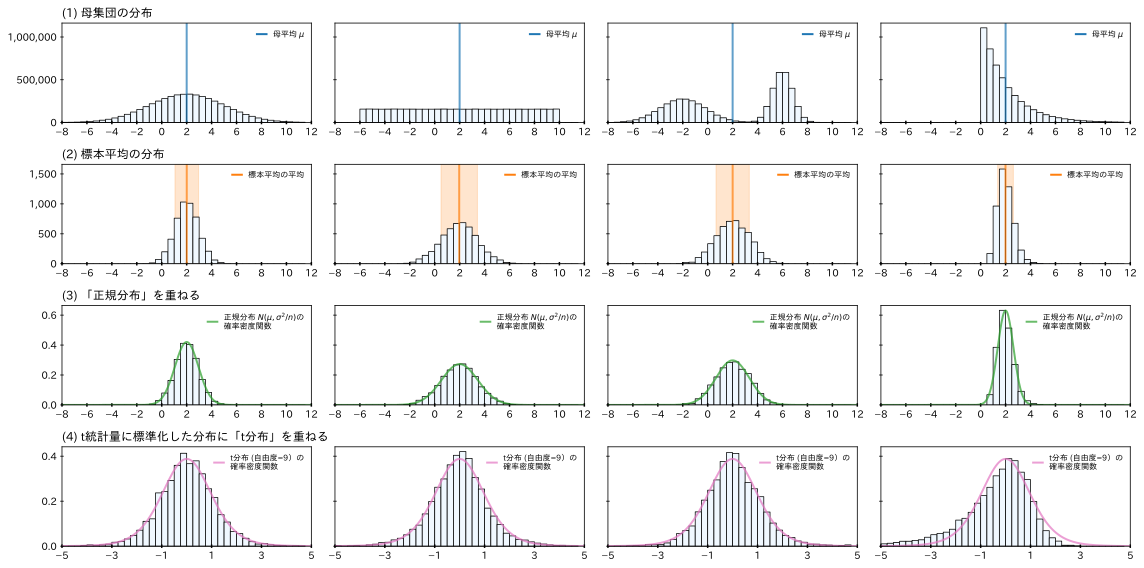

In [ ]:
#@title 標本平均から計算される統計量 t が「t分布」に従うことを確認する補足実験 { display-mode: "form" }
%reset -f

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tk
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 共通設定
def set_common_axis_style(ax):
  assert isinstance(ax, matplotlib.axes.Axes)
  ax.tick_params(axis='x',direction='inout',width=1.5)
  ax.tick_params(axis='y',direction='inout')

# ■ 1. 母集団の生成
# - 母集団の平均 loc や、ばらつき scale を変化させて実験してみてください
N = 5_000_000
populations = []
populations.append(np.random.normal(loc=2,scale=3,size=N))
populations.append(np.random.uniform(low=-6, high=10, size=N))
p1 = np.random.normal(loc=-2,scale=1.8,size=N//2)
p2 = np.random.normal(loc=6,scale=0.8,size=N//2)
populations.append(np.concatenate([p1,p2]))
populations.append(np.random.exponential(scale=2.0, size=N))

ncols, nrows = (len(populations), 4)
fig,axes = plt.subplots(nrows=nrows, ncols=ncols, sharey='row',
                        figsize=(4*ncols, 2*nrows), facecolor='white')
for i, population in enumerate(populations):

  # ■ 2. 母集団の分布（ヒストグラム）
  ax = axes[0][i]
  ax.set_title('(1) 母集団の分布', loc='left') if i == 0 else None
  x_min, x_max, bw = (-8,12,0.5)
  bins = np.arange(x_min,x_max,bw)
  mu = population.mean() # 母平均（真値）
  sigma = population.std(ddof=0) # 母分散（真値）
  ax.axvline(mu,c='tab:blue',lw=2, alpha=0.7)
  hist = ax.hist(population, bins, color='aliceblue', edgecolor ='black',linewidth=0.75)
  ax.set_xticks(np.arange(x_min,x_max+1,2))
  ax.set_xlim(x_min,x_max)
  set_common_axis_style(ax)
  legend_elements = [Line2D([0], [0], color='tab:blue',lw=2,label='母平均 $\\mu$')]
  ax.legend(handles=legend_elements,fontsize=8,handlelength=1.2,frameon=False)
  ax.yaxis.set_major_formatter(tk.FuncFormatter(lambda x, pos=None : f'{x:,.0f}'))

  # 標本抽出 n=sample_size m=iterations
  n,m = (10, 5000)
  samples = np.random.choice(population, size=(m,n), replace=True)
  sample_means = samples.mean(axis=1) # 標本平均の計算
  sample_means_ave = sample_means.mean()
  sample_means_sd  = sample_means.std(ddof=0) # 標本平均の標準偏差=標準誤差

  # ■ 3. 標本平均の分布（ヒストグラム）
  ax = axes[1][i]
  ax.set_title('(2) 標本平均の分布', loc='left') if i == 0 else None
  bins = np.arange(x_min,x_max,bw)
  ax.axvline(sample_means_ave,c='tab:orange',lw=2, alpha=0.7) # 標準平均の平均
  ax.axvspan(sample_means_ave - sample_means_sd, # 標準平均の平均±標準誤差
            sample_means_ave + sample_means_sd,
            alpha=0.2, color='tab:orange')
  ax.hist(sample_means, bins, color='aliceblue', edgecolor ='black',linewidth=0.75)
  ax.set_xticks(np.arange(x_min,x_max+1,2))
  ax.set_xlim(x_min,x_max)
  set_common_axis_style(ax)
  legend_elements = [Line2D([0], [0], color='tab:orange',lw=2,label='標本平均の平均')]
  ax.legend(handles=legend_elements,fontsize=8,handlelength=1.2,frameon=False)
  ax.yaxis.set_major_formatter(tk.FuncFormatter(lambda x, pos=None : f'{x:,.0f}'))

  # ■ 4. 標本平均の分布（正規化したヒストグラム）
  ax = axes[2][i]
  ax.set_title('(3) 「正規分布」を重ねる', loc='left') if i == 0 else None
  bins = np.arange(x_min,x_max,bw)
  ax.hist(sample_means, bins, color='aliceblue', edgecolor ='black',linewidth=0.75, density=True)
  ax.set_xticks(np.arange(x_min,x_max+1,2))
  ax.set_xlim(x_min,x_max)
  set_common_axis_style(ax)
  ax.yaxis.set_major_formatter(tk.FuncFormatter(lambda x, pos=None : f'{x:.1f}'))

  # 平均 mu、分散 sigma^2/n の正規分布の確率密度関数を重ねる
  x = np.linspace(x_min, x_max, 400)
  norm_dist_pdf = st.norm.pdf(x, loc=mu, scale=sigma/n**0.5)
  ax.plot(x, norm_dist_pdf, color='tab:green', lw=2, alpha=0.7,
          label=f'正規分布 $N(\\mu,\\sigma^2/n)$の\n確率密度関数')
  ax.legend(fontsize=8,handlelength=1.2,frameon=False)

  # ■ 5. 標本平均を統計量 t に標準化した分布（ヒストグラム）
  ax = axes[3][i]
  w = 0.5*(x_max-x_min)//2
  bins = np.arange(-w,w,bw/2)
  ax.set_title('(4) t統計量に標準化した分布に「t分布」を重ねる', loc='left') if i == 0 else None
  sample_stds = samples.std(axis=1, ddof=1)  # 各標本ごとの不偏標準偏差
  t_stats = (sample_means - mu) / (sample_stds/n**0.5) # t統計量に変換
  ax.hist(t_stats, bins, color='aliceblue', edgecolor ='black',linewidth=0.75,density=True)
  ax.set_xticks(np.arange(-w,w+1,2))
  ax.set_xlim(-w,w)
  set_common_axis_style(ax)
  ax.yaxis.set_major_formatter(tk.FuncFormatter(lambda x, pos=None : f'{x:.1f}'))

  # 自由度 n−1 のt分布の確率密度関数を重ねる
  x = np.linspace(-w, w, 400)
  t_dist_pdf = st.t.pdf(x, df=n-1)
  ax.plot(x, t_dist_pdf, color='tab:pink', lw=2, alpha=0.7,
          label=f't分布 (自由度={n-1}）の\n確率密度関数')
  ax.legend(fontsize=8,handlelength=1.2,frameon=False)

  # ◆ 標準正規分布を確率密度関数を重ねてみる => わずかにずれる
  # norm_dist_pdf = st.norm.pdf(x, loc=0, scale=1)
  # ax.plot(x, norm_dist_pdf, color='tab:green', lw=2, alpha=0.7,
  #         label=f'標準正規分布の\n確率密度関数')
  # ax.legend(fontsize=8,handlelength=1.2,frameon=False)

plt.tight_layout()
plt.show()

次のことを確認してください。

- Q-Qプロットを用いて、統計量 $t$ の分布が、自由度 $n-1$ の $t$ 分布に従うことを評価してください。また、標準正規分布とも比較してください。
  - Q-Q プロットについては、各自で調べて実装してください。
- 母集団から抽出した標本平均 $\bar{x}$ が「$t$分布」に従うためには、母集団が正規分布に従うことが前提条件となっています。しかし、実際の実験結果から分かるように、極端な分布でなければ、正規母集団でない場合であっても「$t$分布」に従うことが確認できます。

以上で、次のように母平均 $\mu$ の区間推定ができることを説明する「**<font color="deeppink">前準備</font>**」が整いました。

$$\left[ \bar{x} - t \cdot \frac{u}{\sqrt{n}},\; \bar{x} + t \cdot \frac{u}{\sqrt{n}} \right] $$

次週は、この「**<font color="deeppink">前準備</font>**」を基に、区間推定の原理、検定について詳しく学んでいきます。

## **95%信頼区間の意味（オプション）**

信頼区間に関して**よくある誤解**として、次のようなものがあります。

> $95\%$ の確率で、この区間内に母平均 $\mu$ が存在している

これは直感的で、一見正しく思える解釈となります。しかし、確率的に変動するのは「**母平均**」ではなく「**信頼区間の方**」です。母平均 $\mu$ は未知ではあるものの、ある $1$ つの固定された値であり、ランダムに動くわけではありません。

正しい理解は、次のようになります。

> 同じ手法で母集団から何度もサンプリングし、そのたびに信頼区間を計算したとしたら、得られた区間全体のうち $95\%$ が真の母平均 $\mu$ を含むはずである

これは、信頼区間の解釈が「長期的な頻度」に基づくことを意味しています。いま手元にある $1$ つの信頼区間が真の値を含んでいるかは分かりませんが、同じ手続きで求められた信頼区間全体を通してみれば、そのうち $95\%$ が真の値を含む、という保証があります。

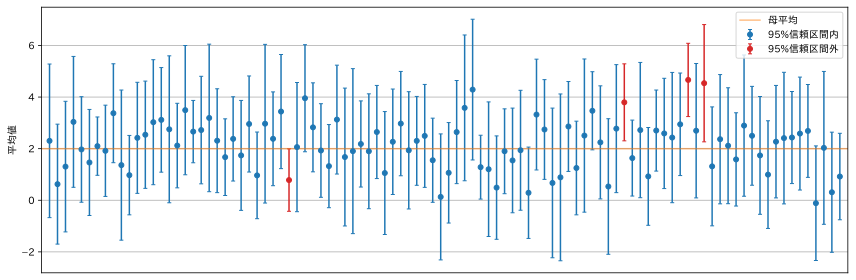

母集団平均: 1.9980
95%信頼区間内に母平均を含む標本数: 96/100 (96.0%)


In [ ]:
#@title 95%信頼区間の意味を理解するための補足実験 { display-mode: "form" }
%reset -f

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tk
import japanize_matplotlib
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 母集団の生成
# - 母集団の分布の切替えて実験してみてください
# - 母集団のばらつき scale を変化させて実験してみてください
population = np.random.normal(loc=2,scale=3,size=5_000_000)
mu = population.mean() # 母平均を計算

# 無作為抽出 n と m を変化させて実験してみてください
n = 10   # サンプルサイズ
m = 100  # サンプリング回数
samples = np.random.choice(population, size=(m,n), replace=True)

# 標本平均の計算
sample_means = np.mean(samples, axis=1)

# 各標本の不偏標準偏差を計算
sample_stds = np.std(samples, axis=1, ddof=1)

# 標準誤差SEを計算
standard_errors = sample_stds / np.sqrt(n)

# t分布の臨界値を計算（95%信頼区間）
alpha = 0.05  # 有意水準
p = 1 - alpha / 2 # 累積確率 97.5%（上側2.5%点）
t = st.t.ppf(p, df=n-1)

# 95%信頼区間の幅を計算
ci = t * standard_errors

fig, ax = plt.subplots(figsize=(12, 4), facecolor='white', dpi=150)

# 信頼区間に母集団平均が含まれるかどうかのマスクを作成
in_ci_mask = (sample_means - ci <= mu) & (mu <= sample_means + ci)
out_ci_mask = ~in_ci_mask

# 信頼区間が母平均を含む場合を青で描画
ax.errorbar(np.arange(m)[in_ci_mask], sample_means[in_ci_mask], yerr=ci[in_ci_mask],
            capsize=2, ecolor='tab:blue', markerfacecolor='tab:blue', markeredgecolor='tab:blue',
            linestyle='none', marker='o', markersize=5, label='95%信頼区間内')

# 信頼区間が母平均を含まない場合を赤で描画
ax.errorbar(np.arange(m)[out_ci_mask], sample_means[out_ci_mask], yerr=ci[out_ci_mask],
            capsize=2, ecolor='tab:red', markerfacecolor='tab:red', markeredgecolor='tab:red',
            linestyle='none', marker='o', markersize=5, label='95%信頼区間外')

# 母平均の描画
ax.axhline(mu, color='tab:orange', label='母平均',alpha=0.5)

# グラフの設定
ax.set_ylabel('平均値')
ax.set_xticks([])
ax.set_xlim(-1,m)
ax.grid(axis='y')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 信頼区間に母平均を含む標本数をカウント
covered_count = sum(in_ci_mask)

print(f"母集団平均: {mu:.4f}")
print(f"95%信頼区間内に母平均を含む標本数: {covered_count}/{m} ({covered_count/m*100:.1f}%)")